<a href="https://www.kaggle.com/code/hamidgujjar/efficientnet-b4-cleaned?scriptVersionId=346742917" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# ============================================================
# STEP 1: Environment Setup & Reproducibility
# ============================================================

# Basic libraries
import os
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

# Torchvision
import torchvision
from torchvision import transforms, models

# Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    cohen_kappa_score
)
from sklearn.model_selection import StratifiedShuffleSplit

# Utilities
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# ============================================================
# Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# STEP 2: Load Dataset & Verify Image Paths
# ============================================================

# Dataset paths
DATA_DIR = "/kaggle/input/aptos-2019-balanced-dataset"
CSV_PATH = "/kaggle/input/datasets/amanp143/aptos-2019-balanced-dataset/labels.csv"
IMG_DIR = "/kaggle/input/datasets/amanp143/aptos-2019-balanced-dataset/balanced_dataset/balanced_dataset"

# Load CSV
df = pd.read_csv(CSV_PATH)

print("Total samples:", len(df))
display(df.head())

# Class distribution
print("\nClass Distribution:")
print(df["diagnosis"].value_counts().sort_index())

# Verify image existence
missing_images = []

for idx in range(len(df)):
    img_path = os.path.join(IMG_DIR, df.loc[idx, "id_code"])
    if not os.path.exists(img_path):
        missing_images.append(img_path)

print("\nMissing images:", len(missing_images))


Total samples: 9025


,id_code,diagnosis
0,002c21358ce6.png,0
1,005b95c28852.png,0
2,0097f532ac9f.png,0
3,00cc2b75cddd.png,0
4,00f6c1be5a33.png,0



Class Distribution:
diagnosis
0    1805
1    1805
2    1805
3    1805
4    1805
Name: count, dtype: int64

Missing images: 0


In [3]:
# ============================================================
# STEP 3: Stratified Train / Validation Split
# ============================================================
# Split configuration
TEST_SIZE = 0.2

splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED
)

for train_idx, val_idx in splitter.split(df, df["diagnosis"]):
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

# Verify split sizes
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))

# Verify class balance
print("\nTrain class distribution:")
print(train_df["diagnosis"].value_counts().sort_index())

print("\nValidation class distribution:")
print(val_df["diagnosis"].value_counts().sort_index())


Train samples: 7220
Validation samples: 1805

Train class distribution:
diagnosis
0    1444
1    1444
2    1444
3    1444
4    1444
Name: count, dtype: int64

Validation class distribution:
diagnosis
0    361
1    361
2    361
3    361
4    361
Name: count, dtype: int64


In [4]:
# ============================================================
# STEP 4: Image Preprocessing & Augmentations
# ============================================================

# Image size
IMG_SIZE = 384

# Normalization (ImageNet — required for pretrained models)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Training transforms (strong but safe)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Validation transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

print("Train & Validation transforms defined successfully")


Train & Validation transforms defined successfully


In [5]:
# ============================================================
# STEP 5: Custom PyTorch Dataset Class
# ============================================================

class APTOSDataset(Dataset):
    def __init__(self, dataframe, image_dir, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Image name from CSV
        img_name = self.df.loc[idx, "id_code"]

        # Handle filenames safely (with or without extension)
        if img_name.endswith(".png"):
            img_file = img_name
        else:
            img_file = f"{img_name}.png"

        img_path = os.path.join(self.image_dir, img_file)

        # Load image
        image = Image.open(img_path).convert("RGB")

        # Label
        label = int(self.df.loc[idx, "diagnosis"])

        # Apply transforms
        if self.transforms is not None:
            image = self.transforms(image)

        return image, label


print("STEP 5 completed successfully")


STEP 5 completed successfully


In [6]:
# ============================================================
# STEP 6: DataLoaders (Train & Validation)
# ============================================================

BATCH_SIZE = 8
NUM_WORKERS = 2
PIN_MEMORY = True

train_dataset = APTOSDataset(
    dataframe=train_df,
    image_dir=IMG_DIR,
    transforms=train_transforms
)

val_dataset = APTOSDataset(
    dataframe=val_df,
    image_dir=IMG_DIR,
    transforms=val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Sanity check
images, labels = next(iter(train_loader))
print("Train batch images shape:", images.shape)
print("Train batch labels shape:", labels.shape)

print("STEP 6 completed successfully")


Train batch images shape: torch.Size([8, 3, 384, 384])
Train batch labels shape: torch.Size([8])
STEP 6 completed successfully


In [7]:
import os

DATA_DIR = "/kaggle/input/aptos-2019-balanced-dataset"

for root, dirs, files in os.walk(DATA_DIR):
    depth = root.replace(DATA_DIR, "").count(os.sep)
    print("  " * depth + os.path.basename(root) + "/")
    for f in files[:3]:
        print("  " * (depth + 1) + f)
    if depth > 3:
        dirs.clear()  # stop descending too deep

In [8]:
# ============================================================
# STEP 7: Model Architecture (EfficientNet-B4)
# ============================================================

NUM_CLASSES = 5

class APTOSModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # Load pretrained EfficientNet-B4
        self.backbone = models.efficientnet_b4(weights="IMAGENET1K_V1")

        # Feature dimension
        in_features = self.backbone.classifier[1].in_features

        # Replace classifier head
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


# Instantiate model
model = APTOSModel(num_classes=NUM_CLASSES).to(device)

# Verify classifier
print(model.backbone.classifier)

print("STEP 7 (EfficientNet-B4) completed successfully")


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 162MB/s]


Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1792, out_features=5, bias=True)
)
STEP 7 (EfficientNet-B4) completed successfully


In [9]:
# ============================================================
# STEP 8: Loss Function (Combined Cross-Entropy + QWK, GPU safe)
# ============================================================

# ---------------------------
# Differentiable QWK Loss (GPU safe)
# ---------------------------
class QWKLoss(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.num_classes = num_classes

        W = torch.tensor(
            [[(i - j) ** 2 for j in range(num_classes)]
             for i in range(num_classes)],
            dtype=torch.float
        )

        self.register_buffer("W", W)

    def forward(self, logits, targets):
        device = logits.device

        probs = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, self.num_classes).float()

        W = self.W.to(device)

        O = torch.sum(W * torch.matmul(targets_onehot.T, probs))
        E = torch.sum(W * torch.matmul(
            targets_onehot.sum(0).view(-1, 1),
            probs.sum(0).view(1, -1)
        ))

        qwk = 1 - O / (E + 1e-6)
        return 1 - qwk


# ---------------------------
# Combined Loss
# ---------------------------
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.7):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.qwk = QWKLoss(NUM_CLASSES)
        self.alpha = alpha

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        qwk_loss = self.qwk(logits, targets)
        return self.alpha * ce_loss + (1 - self.alpha) * qwk_loss


# Instantiate criterion
criterion = CombinedLoss(alpha=0.7)

print("STEP 8 (combined loss) completed successfully")


STEP 8 (combined loss) completed successfully


In [10]:
# ============================================================
# STEP 9: Optimizer & Learning Rate Scheduler
# ============================================================

# ---------------------------
# Hyperparameters
# ---------------------------
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 15   # can increase later after validation check

# ---------------------------
# Optimizer
# ---------------------------
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ---------------------------
# Scheduler (Cosine Annealing)
# ---------------------------
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

print("Optimizer:", optimizer.__class__.__name__)
print("Scheduler:", scheduler.__class__.__name__)
print("Initial LR:", optimizer.param_groups[0]["lr"])

print("STEP 9 completed successfully")


Optimizer: AdamW
Scheduler: CosineAnnealingLR
Initial LR: 0.0003
STEP 9 completed successfully


In [11]:
# ============================================================
# STEP 10: Training & Validation Loop (AMP-enabled)
# ============================================================

# ---------------------------
# AMP scaler
# ---------------------------
scaler = torch.cuda.amp.GradScaler()

BEST_QWK = -1.0
MODEL_SAVE_PATH = "best_aptos_model_b4.pth"

# ============================================================
# Train one epoch
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)


# ============================================================
# Validation
# ============================================================
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()

    val_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)

        val_loss += loss.item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())
        all_probs.extend(probs.cpu().float().numpy())  # force FP32

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Re-normalize probabilities (required for sklearn ROC with AMP)
    all_probs = all_probs / all_probs.sum(axis=1, keepdims=True)

    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    roc = roc_auc_score(all_labels, all_probs, multi_class="ovr")
    cm = confusion_matrix(all_labels, all_preds)

    return val_loss / len(loader), acc, qwk, roc, cm


# ============================================================
# Training Loop
# ============================================================
for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_qwk, val_roc, val_cm = validate(
        model, val_loader, criterion
    )

    scheduler.step()

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Accuracy   : {val_acc:.4f}")
    print(f"QWK        : {val_qwk:.4f}")
    print(f"ROC-AUC    : {val_roc:.4f}")
    print("Confusion Matrix:\n", val_cm)

    # Save best model by QWK
    if val_qwk > BEST_QWK:
        BEST_QWK = val_qwk
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Best model saved! New Best QWK: {BEST_QWK:.4f}")

print("\nTRAINING COMPLETED")
print("Best QWK achieved:", BEST_QWK)
print("Model saved as:", MODEL_SAVE_PATH)



Epoch [1/15]


Train Loss : 0.6256
Val Loss   : 0.4207
Accuracy   : 0.7723
QWK        : 0.8710
ROC-AUC    : 0.9499
Confusion Matrix:
 [[360   1   0   0   0]
 [ 17 329  10   2   3]
 [  2 132 196  23   8]
 [  0  12  42 275  32]
 [  2  30  46  49 234]]
Best model saved! New Best QWK: 0.8710

Epoch [2/15]


Train Loss : 0.4025
Val Loss   : 0.2609
Accuracy   : 0.8681
QWK        : 0.9341
ROC-AUC    : 0.9797
Confusion Matrix:
 [[355   6   0   0   0]
 [  5 346  10   0   0]
 [  2  71 263  23   2]
 [  0   0  20 323  18]
 [  0  15  32  34 280]]
Best model saved! New Best QWK: 0.9341

Epoch [3/15]


Train Loss : 0.2771
Val Loss   : 0.1630
Accuracy   : 0.9191
QWK        : 0.9659
ROC-AUC    : 0.9915
Confusion Matrix:
 [[352   9   0   0   0]
 [  2 333  25   0   1]
 [  1  28 312  14   6]
 [  0   0  12 344   5]
 [  0   2  17  24 318]]
Best model saved! New Best QWK: 0.9659

Epoch [4/15]


Train Loss : 0.2080
Val Loss   : 0.1419
Accuracy   : 0.9363
QWK        : 0.9723
ROC-AUC    : 0.9946
Confusion Matrix:
 [[353   7   1   0   0]
 [  3 341  16   0   1]
 [  1  18 327  12   3]
 [  0   0   3 358   0]
 [  0   2  14  34 311]]
Best model saved! New Best QWK: 0.9723

Epoch [5/15]


...

Train Loss : 0.0482
Val Loss   : 0.0761
Accuracy   : 0.9668
QWK        : 0.9852
ROC-AUC    : 0.9986
Confusion Matrix:
 [[357   4   0   0   0]
 [  4 355   1   0   1]
 [  0  10 342   6   3]
 [  0   0   1 358   2]
 [  0   1   7  20 333]]

Epoch [12/15]


Train Loss : 0.0436
Val Loss   : 0.0757
Accuracy   : 0.9701
QWK        : 0.9856
ROC-AUC    : 0.9986
Confusion Matrix:
 [[356   4   1   0   0]
 [  2 358   0   0   1]
 [  0   9 342   7   3]
 [  0   0   1 358   2]
 [  1   1   2  20 337]]

Epoch [13/15]


Train Loss : 0.0392
Val Loss   : 0.0781
Accuracy   : 0.9690
QWK        : 0.9851
ROC-AUC    : 0.9986
Confusion Matrix:
 [[355   5   1   0   0]
 [  2 358   0   0   1]
 [  0  10 342   6   3]
 [  0   0   1 358   2]
 [  0   2   5  18 336]]

Epoch [14/15]


Train Loss : 0.0381
Val Loss   : 0.0771
Accuracy   : 0.9701
QWK        : 0.9866
ROC-AUC    : 0.9986
Confusion Matrix:
 [[355   5   1   0   0]
 [  1 359   0   0   1]
 [  0   8 342   7   4]
 [  0   0   1 358   2]
 [  0   2   1  21 337]]

Epoch [15/15]


Train Loss : 0.0404
Val Loss   : 0.0750
Accuracy   : 0.9706
QWK        : 0.9867
ROC-AUC    : 0.9987
Confusion Matrix:
 [[355   5   1   0   0]
 [  1 359   0   0   1]
 [  0   9 343   6   3]
 [  0   0   1 358   2]
 [  0   2   2  20 337]]

TRAINING COMPLETED
Best QWK achieved: 0.9874721603563474
Model saved as: best_aptos_model_b4.pth


Val Loss : 0.0761
Accuracy : 0.9679
QWK      : 0.9875
ROC-AUC  : 0.9982


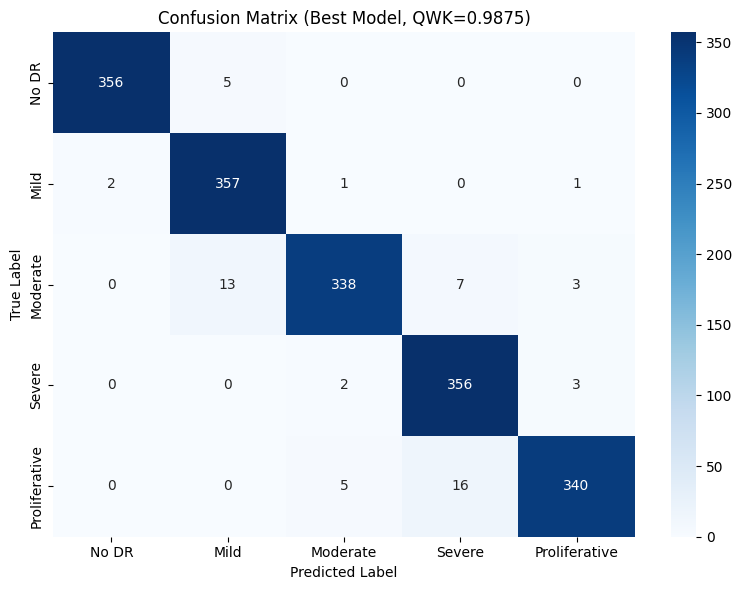

In [12]:
# ====================================================
#     STEP 11: Load Best Model & Final Evaluation 
# ====================================================
# Load best checkpoint 
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()
# Run validation once 
val_loss, val_acc, val_qwk, val_roc, val_cm = validate(
    model, val_loader, criterion
)
print(f"Val Loss : {val_loss:.4f}")
print(f"Accuracy : {val_acc:.4f}")
print(f"QWK      : {val_qwk:.4f}")
print(f"ROC-AUC  : {val_roc:.4f}")
# Plot confusion matrix
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
plt.figure(figsize=(8, 6))
sns.heatmap(
    val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix (Best Model, QWK={val_qwk:.4f})")
plt.tight_layout()
plt.show()